# Vì sao khách không quay lại, và vận hành sửa được gì?

**Vị trí trong dự án:** Notebook 01 trả lời *khách hàng là ai và nhóm nào đáng đầu tư*; notebook 02
trả lời *khi nào một khách được coi là đã mất, can thiệp lúc nào và đáng bao nhiêu tiền*. Còn lại
câu hỏi về nguyên nhân: điều gì trong trải nghiệm mua hàng khiến 97.8% khách không quay lại, và bộ
phận vận hành có thể thay đổi được phần nào trong đó.

**Giả thuyết ban đầu** (`business_analysis.md`, Bài toán 3): khách rời đi vì trải nghiệm giao hàng
xấu — giao trễ, phí vận chuyển cao, đánh giá thấp. Notebook này kiểm tra giả thuyết đó bằng cách so
sánh hành vi *sau* lần mua đầu, rồi đi tiếp ở chỗ giả thuyết không giải thích được.

**Bốn câu hỏi:**

1. Trải nghiệm lần mua đầu (điểm đánh giá, giao trễ, vùng địa lý) ảnh hưởng bao nhiêu đến việc
   khách quay lại? — phần 2 và 3
2. Giao trễ tác động lên điểm đánh giá ra sao, và bao nhiêu phần đánh giá xấu là do giao hàng? — phần 4
3. Vận hành có thể sửa gì: ngày hẹn giao, seller gây trễ, giao hàng liên bang? — phần 5 và 6
4. Nếu vận hành không phải lý do chính, thì lý do quay lại nằm ở đâu: giỏ hàng, danh mục, seller quen? — phần 7

**Dữ liệu:** 96,477 đơn đã giao thành công từ `gold.fact_orders`, `gold.fact_order_items`,
`gold.dim_customers`, `gold.dim_products`, `gold.dim_sellers`; mốc thời gian ước tính giao hàng lấy
từ bronze `olist_orders` vì lớp gold chỉ giữ số ngày chênh lệch.

**Quy ước dùng xuyên suốt** (giống notebook 01 và 02): khách = `customer_unique_id`; một *lần mua*
= một ngày mua riêng biệt (gộp các đơn bị tách trong cùng lần thanh toán); khách *mua lại* = có từ
hai lần mua trở lên; đơn *giao trễ* = `order_delay_day > 0`, tức là giao sau ngày hẹn.

## 1. Chuẩn bị dữ liệu

In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
db_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(db_url)

### 1.1. Bảng đơn hàng

Mỗi dòng là một đơn đã giao. Ghép thêm vùng của khách (`dim_customers`) và hai mốc thời gian từ
bronze để tính số ngày giao *sớm hơn* hẹn — thông tin mà cột `order_delay_day` (chỉ có nghĩa khi
dương) không giữ được.

In [2]:
orders = pd.read_sql("""
    SELECT f.order_id,
           f.customer_unique_id,
           f.order_purchase_date,
           f.total_payment_value,
           f.order_freight,
           f.order_review_score,
           f.order_delivery_day,
           f.order_delay_day,
           f.order_payment_type,
           f.order_payment_installment,
           f.days_transit,
           c.customer_state,
           c.customer_region,
           o.order_estimated_delivery_date::date  AS estimated_date,
           o.order_delivered_customer_date::date  AS delivered_date
    FROM gold.fact_orders f
    JOIN gold.dim_customers c ON c.customer_unique_id = f.customer_unique_id
    JOIN olist_orders o       ON o.order_id = f.order_id
""", engine)

for col in ['order_purchase_date', 'estimated_date', 'delivered_date']:
    orders[col] = pd.to_datetime(orders[col])

orders['is_late']    = orders['order_delay_day'] > 0
orders['days_early'] = (orders['estimated_date'] - orders['delivered_date']).dt.days   # dương = giao sớm

print(f"{len(orders):,} đơn · {orders['customer_unique_id'].nunique():,} khách")
print(f"Tỷ lệ giao trễ: {orders['is_late'].mean()*100:.2f}%")

96,477 đơn · 93,357 khách
Tỷ lệ giao trễ: 6.77%


### 1.2. Thông tin giỏ hàng và seller theo đơn

`fact_order_items` có một dòng cho mỗi món hàng. Gộp về mức đơn để biết mỗi đơn có bao nhiêu
món, bao nhiêu sản phẩm khác nhau, từ bao nhiêu seller, thuộc danh mục nào và seller ở bang nào.
Đơn có nhiều danh mục hoặc nhiều seller (rất hiếm, kiểm tra ở phần 7) lấy theo món đầu tiên.

In [3]:
items = pd.read_sql("""
    SELECT i.order_id, i.order_item_id, i.product_id, i.seller_id, i.price, i.freight_value,
           p.product_category_name_english AS category,
           s.seller_state
    FROM gold.fact_order_items i
    LEFT JOIN gold.dim_products p ON p.product_id = i.product_id
    LEFT JOIN gold.dim_sellers  s ON s.seller_id  = i.seller_id
    ORDER BY i.order_id, i.order_item_id
""", engine)

basket = items.groupby('order_id').agg(
    n_items      = ('order_item_id', 'count'),
    n_products   = ('product_id', 'nunique'),
    n_sellers    = ('seller_id', 'nunique'),
    items_price  = ('price', 'sum'),
    category     = ('category', 'first'),
    seller_state = ('seller_state', 'first'),
)
orders = orders.merge(basket, left_on='order_id', right_index=True, how='left')
orders['is_cross_state'] = orders['seller_state'] != orders['customer_state']

print(f"Đơn có thông tin giỏ hàng: {orders['n_items'].notna().sum():,} / {len(orders):,}")

Đơn có thông tin giỏ hàng: 96,477 / 96,477


### 1.3. Thứ tự lần mua và nhãn khách mua lại

Áp lại định nghĩa *lần mua* của notebook 02: một ngày mua riêng biệt của một khách. Mỗi đơn được
gán số thứ tự lần mua (`purchase_seq`); khách có `purchase_seq` tối đa từ 2 trở lên là khách mua lại.

In [4]:
occasions = (orders[['customer_unique_id', 'order_purchase_date']]
             .drop_duplicates()
             .sort_values(['customer_unique_id', 'order_purchase_date']))
occasions['purchase_seq'] = occasions.groupby('customer_unique_id').cumcount() + 1

orders = orders.merge(occasions, on=['customer_unique_id', 'order_purchase_date'], how='left')
n_occ = occasions.groupby('customer_unique_id')['purchase_seq'].max()
orders['is_repeat_customer'] = orders['customer_unique_id'].map(n_occ) >= 2

n_cust   = orders['customer_unique_id'].nunique()
n_repeat = (n_occ >= 2).sum()
print(f"Khách mua lại: {n_repeat:,} / {n_cust:,} = {n_repeat/n_cust*100:.2f}%")

Khách mua lại: 2,015 / 93,357 = 2.16%


**Kiểm tra:** 2,015 khách mua lại (2.16%) — khớp với notebook 02 và bảng KPI trong
`business_analysis.md`. Toàn bộ phân tích bên dưới dùng nhãn này, không dùng số đếm theo `order_id`.

### 1.4. Bảng lần mua đầu tiên

Nhiều câu hỏi xoay quanh *lần mua đầu*: trải nghiệm lúc đó có quyết định việc khách quay lại
không. Gộp các đơn của lần mua đầu (thường chỉ một đơn, đôi khi vài đơn bị tách) thành một dòng
cho mỗi khách: điểm đánh giá trung bình, có đơn nào giao trễ không, danh mục và vùng.

In [5]:
first = (orders[orders['purchase_seq'] == 1]
         .groupby('customer_unique_id')
         .agg(first_review   = ('order_review_score', 'mean'),
              first_late     = ('is_late', 'max'),
              first_category = ('category', 'first'),
              first_value    = ('total_payment_value', 'sum'),
              region         = ('customer_region', 'first'))
         .reset_index())
first['is_repeat'] = first['customer_unique_id'].map(n_occ) >= 2

print(f"{len(first):,} khách · tỷ lệ mua lại chung: {first['is_repeat'].mean()*100:.2f}%")

93,357 khách · tỷ lệ mua lại chung: 2.16%


## 2. Trải nghiệm lần mua đầu có quyết định việc quay lại không?

`business_analysis.md` đặt giả thuyết rằng khách rời đi vì trải nghiệm xấu (giao trễ, đánh giá
thấp). Nếu đúng, khách có lần mua đầu tệ phải quay lại ít hơn rõ rệt so với khách hài lòng. Đây là
cách kiểm tra trực tiếp nhất, vì nó so sánh hành vi *sau* trải nghiệm thay vì so sánh các phân khúc
đã hình thành.

In [6]:
first['review_band'] = pd.cut(first['first_review'], bins=[0, 2, 3, 5],
                              labels=['1–2 sao', '3 sao', '4–5 sao'])

by_review = (first.dropna(subset=['review_band'])
             .groupby('review_band', observed=True)['is_repeat']
             .agg(so_khach='size', ty_le_mua_lai='mean'))
by_review['ty_le_mua_lai'] = (by_review['ty_le_mua_lai'] * 100).round(2)

by_late = first.groupby('first_late')['is_repeat'].agg(so_khach='size', ty_le_mua_lai='mean')
by_late['ty_le_mua_lai'] = (by_late['ty_le_mua_lai'] * 100).round(2)
by_late.index = by_late.index.map({False: 'Đúng hẹn', True: 'Giao trễ'})

print("Tỷ lệ mua lại theo điểm đánh giá lần mua đầu (%):")
print(by_review.to_string())
print("\nTỷ lệ mua lại theo tình trạng giao hàng lần mua đầu (%):")
print(by_late.to_string())

Tỷ lệ mua lại theo điểm đánh giá lần mua đầu (%):
             so_khach  ty_le_mua_lai
review_band                         
1–2 sao         11884           1.72
3 sao            7685           1.95
4–5 sao         73174           2.25

Tỷ lệ mua lại theo tình trạng giao hàng lần mua đầu (%):
            so_khach  ty_le_mua_lai
first_late                         
Đúng hẹn       86971           2.20
Giao trễ        6386           1.61


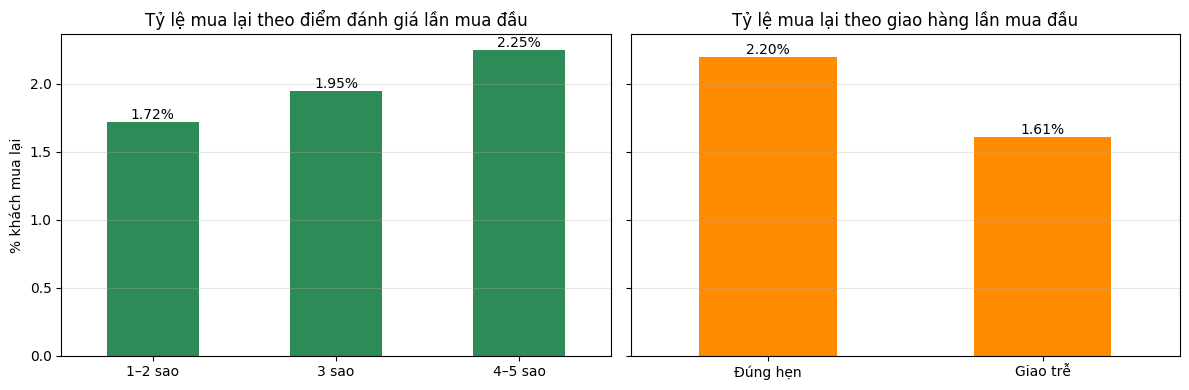

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
by_review['ty_le_mua_lai'].plot.bar(ax=axes[0], color='seagreen', rot=0)
axes[0].set_title('Tỷ lệ mua lại theo điểm đánh giá lần mua đầu')
axes[0].set_xlabel(''); axes[0].set_ylabel('% khách mua lại')
by_late['ty_le_mua_lai'].plot.bar(ax=axes[1], color='darkorange', rot=0)
axes[1].set_title('Tỷ lệ mua lại theo giao hàng lần mua đầu')
axes[1].set_xlabel('')
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')
    ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()

**Observation**
- Khách có lần mua đầu bị 1–2 sao quay lại với tỷ lệ 1.72%, so với 2.25% ở nhóm 4–5 sao.
- Khách có lần mua đầu giao trễ quay lại 1.61%, so với 2.20% ở nhóm giao đúng hẹn.
- Cả hai chênh lệch đều cùng chiều với giả thuyết, nhưng biên độ chỉ khoảng 0.5 điểm phần trăm.

**Meaning**
- Trải nghiệm xấu làm giảm khoảng một phần tư xác suất quay lại (từ 2.2% xuống 1.6–1.7%). Đây là
  ảnh hưởng thật và đo được, nên vận hành vẫn đáng sửa.
- Nhưng con số quan trọng hơn là 2.25%: ngay cả khách hài lòng và được giao đúng hẹn cũng gần như
  không quay lại. Nếu Olist giao đúng hẹn cho toàn bộ khách và ai cũng cho 5 sao, tỷ lệ mua lại
  chỉ nhích từ 2.16% lên khoảng 2.2%. Vấn đề giữ chân không nằm ở chất lượng giao hàng mà ở mô
  hình kinh doanh: khách đến Olist để mua một món cụ thể rồi không có lý do quay lại.

**Action**
- Xếp cải thiện vận hành vào nhóm *bảo vệ doanh thu hiện có* (phần 4 cho thấy nó bảo vệ điểm đánh
  giá và nhóm At Risk), không phải nhóm *tăng tỷ lệ mua lại*.
- Chiến dịch giữ chân cần tạo lý do quay lại (danh mục mua lặp, ưu đãi đơn thứ hai — xem phần 7)
  thay vì chỉ sửa lỗi giao hàng.

## 3. Vùng địa lý: mua lại, giao trễ và phí vận chuyển

Mua lại, giao trễ và phí vận chuyển đều thay đổi theo vùng. Đặt ba chỉ số cạnh nhau trong một bảng
để thấy chúng có cùng thứ tự hay không — nếu có, đó là một hiện tượng chứ không phải ba. Phí vận chuyển tính theo tỷ lệ trên giá
hàng (`order_freight / items_price`) để so sánh được giữa các vùng có mức giá khác nhau.

In [8]:
by_region = orders.groupby('customer_region').agg(
    so_don        = ('order_id', 'size'),
    ty_le_tre     = ('is_late', 'mean'),
    ngay_giao     = ('order_delivery_day', 'mean'),
    ngay_transit  = ('days_transit', 'mean'),
    phi_ship_tb   = ('order_freight', 'mean'),
    tong_phi_ship = ('order_freight', 'sum'),
    tong_gia_hang = ('items_price', 'sum'),
    aov           = ('total_payment_value', 'mean'),
)
by_region['phi_ship_pct'] = by_region['tong_phi_ship'] / by_region['tong_gia_hang'] * 100
by_region['ty_le_tre']    = by_region['ty_le_tre'] * 100

rep_region = first.groupby('region')['is_repeat'].mean() * 100
by_region['ty_le_mua_lai'] = rep_region

by_region = (by_region[['so_don', 'ty_le_mua_lai', 'ty_le_tre', 'ngay_giao', 'ngay_transit',
                        'phi_ship_tb', 'phi_ship_pct', 'aov']]
             .sort_values('ty_le_mua_lai', ascending=False)
             .round(2))
by_region

,so_don,ty_le_mua_lai,ty_le_tre,ngay_giao,ngay_transit,phi_ship_tb,phi_ship_pct,aov
customer_region,,,,,,,,
Southeast,66203,2.29,6.12,10.69,7.54,19.84,15.19,150.52
South,13813,2.05,5.90,13.98,10.79,24.34,17.69,162.00
Central-West,5619,1.95,6.50,14.95,11.85,26.48,17.58,177.17
North,1797,1.84,8.57,22.54,19.24,41.35,22.71,223.45
Northeast,9045,1.59,12.71,19.94,16.64,35.98,21.74,201.54


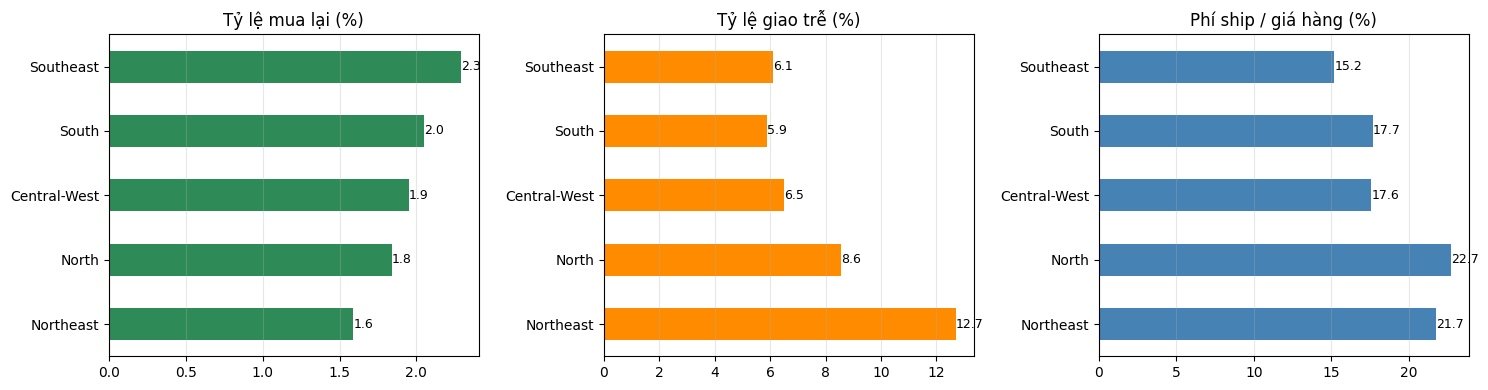

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
        axes,
        ['ty_le_mua_lai', 'ty_le_tre', 'phi_ship_pct'],
        ['Tỷ lệ mua lại (%)', 'Tỷ lệ giao trễ (%)', 'Phí ship / giá hàng (%)'],
        ['seagreen', 'darkorange', 'steelblue']):
    by_region[col].plot.barh(ax=ax, color=color)
    ax.set_title(title); ax.set_ylabel(''); ax.invert_yaxis(); ax.grid(axis='x', alpha=.3)
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.1f}", (p.get_width(), p.get_y() + p.get_height()/2),
                    va='center', ha='left', fontsize=9)
plt.tight_layout()
plt.show()

**Observation**
- Thứ tự mua lại: Southeast 2.29% → South 2.05% → Central-West 1.95% → North 1.84% → Northeast
  1.59%. Chênh lệch giữa vùng cao nhất và thấp nhất là 1.4 lần.
- Thứ tự giao trễ gần như đảo ngược: Northeast (12.7%) và North (8.6%) trễ nhiều nhất, South và Southeast (khoảng 6%) ít nhất.
- Phí vận chuyển chiếm 15% giá hàng ở Southeast nhưng 22–23% ở North và Northeast; phí trung bình
  mỗi đơn ở North gấp đôi Southeast.

**Meaning**
- Ba chỉ số xếp cùng một thứ tự: vùng càng xa trung tâm kinh tế (São Paulo) thì giao càng chậm, phí
  càng cao và khách càng ít quay lại. Đây là cùng một hiện tượng nhìn từ ba phía, không phải ba vấn
  đề riêng.
- Khách North và Northeast trả nhiều hơn cho mỗi đơn (AOV cao hơn Southeast khoảng 35–50%) một phần
  vì phí ship, nên giá trị đơn cao ở các vùng này không phản ánh sức mua cao hơn.

**Action**
- Ưu tiên logistics cho Northeast trước North: Northeast có số đơn gấp 5 lần North, nên cùng một
  mức cải thiện tạo ra nhiều đơn đúng hẹn hơn.
- Khi tính business case theo vùng (notebook 02 phần 3), dùng AOV *trừ phí ship* cho North và
  Northeast, nếu không doanh thu thu hồi sẽ bị ước lượng cao.

## 4. Giao trễ và điểm đánh giá

Phần 2 cho thấy giao trễ ít ảnh hưởng đến việc quay lại. Phần này đo ảnh hưởng của nó lên thứ mà
nó chắc chắn tác động: điểm đánh giá. Ba câu hỏi: đơn trễ bị chấm thấp hơn bao nhiêu, bao nhiêu
phần đánh giá xấu là do giao trễ, và khách mua lại có được giao nhanh hơn khách một lần không.

In [10]:
rated = orders.dropna(subset=['order_review_score']).copy()
rated['is_low'] = rated['order_review_score'] <= 2

review_by_late = rated.groupby('is_late').agg(
    so_don      = ('order_id', 'size'),
    diem_tb     = ('order_review_score', 'mean'),
    ty_le_1_2   = ('is_low', 'mean'),
).round(3)
review_by_late.index = review_by_late.index.map({False: 'Đúng hẹn', True: 'Giao trễ'})
review_by_late['ty_le_1_2'] = (review_by_late['ty_le_1_2'] * 100).round(1)

low = rated[rated['is_low']]
share_low_late = low['is_late'].mean() * 100
base_late      = rated['is_late'].mean() * 100

print("Điểm đánh giá theo tình trạng giao hàng:")
print(review_by_late.to_string())
print(f"\nTrong {len(low):,} đơn bị 1–2 sao: {share_low_late:.1f}% giao trễ "
      f"(tỷ lệ trễ chung: {base_late:.1f}%)")

Điểm đánh giá theo tình trạng giao hàng:
          so_don  diem_tb  ty_le_1_2
is_late                             
Đúng hẹn   89451    4.291        9.2
Giao trễ    6380    2.272       62.4

Trong 12,236 đơn bị 1–2 sao: 32.5% giao trễ (tỷ lệ trễ chung: 6.7%)


In [11]:
delivery_by_repeat = orders.groupby('is_repeat_customer').agg(
    so_don   = ('order_id', 'size'),
    ngay_giao = ('order_delivery_day', 'mean'),
    ty_le_tre = ('is_late', 'mean'),
).round(3)
delivery_by_repeat.index = delivery_by_repeat.index.map({False: 'Khách một lần', True: 'Khách mua lại'})
delivery_by_repeat['ty_le_tre'] = (delivery_by_repeat['ty_le_tre'] * 100).round(2)
delivery_by_repeat

,so_don,ngay_giao,ty_le_tre
is_repeat_customer,,,
Khách một lần,92154,12.534,6.8
Khách mua lại,4323,11.694,5.3


**Observation**
- Đơn giao trễ được chấm trung bình 2.27 sao, đơn đúng hẹn 4.29 sao — chênh 2 sao trên thang 5.
- 62.4% đơn giao trễ bị chấm 1–2 sao, so với 9.2% đơn đúng hẹn.
- Nhưng nhìn từ phía đánh giá xấu: trong số đơn bị 1–2 sao, chỉ 32.5% là giao trễ. Hai phần ba
  đánh giá xấu đến từ đơn giao đúng hẹn.
- Khách mua lại được giao nhanh hơn không đáng kể (11.7 so với 12.5 ngày) và ít bị trễ hơn
  (5.3% so với 6.8%).

**Meaning**
- Giao trễ gần như chắc chắn dẫn đến đánh giá xấu (6 trong 10 đơn), nên với từng đơn, đây là yếu
  tố mạnh nhất. Nhưng vì chỉ 6.8% đơn bị trễ, giao trễ chỉ giải thích được một phần ba tổng số
  đánh giá xấu. Sửa hết giao trễ thì điểm trung bình toàn sàn tăng, nhưng hai phần ba đánh giá
  1–2 sao vẫn còn nguyên.
- Phần đánh giá xấu không do giao trễ là câu hỏi mở: hàng không đúng mô tả, hỏng, hay không nhận
  được dù hệ thống ghi đã giao. Dữ liệu có cột bình luận (77% đánh giá 1 sao có văn bản) nên có thể
  phân tích văn bản để tách nguyên nhân; việc này nằm ngoài phạm vi notebook.
- Khác biệt giao hàng giữa khách mua lại và khách một lần nhỏ, nhất quán với phần 2: giao hàng
  không phải thứ phân biệt hai nhóm.

**Action**
- Với bộ phận vận hành: giảm giao trễ là cách hiệu quả nhất để nâng điểm đánh giá, và phần 6 chỉ ra nó tập
  trung ở ít seller.
- Với bộ phận sản phẩm: cần phân tích riêng 8,000 đánh giá xấu không liên quan giao hàng, bắt đầu
  từ bình luận văn bản.

## 5. Ngày giao dự kiến đang được đặt quá xa?

Đề xuất ban đầu của dự án là "điều chỉnh thời gian giao hàng ước tính thực tế hơn". Câu hỏi
ngược lại chưa được kiểm tra: Olist đang hẹn *quá xa* hay *quá gần*? Nếu phần lớn đơn đến sớm hơn
hẹn nhiều ngày, ngày hẹn đang được đặt xa hơn mức cần thiết, và câu hỏi tiếp theo là giao sớm có làm khách hài lòng hơn
không — nếu không, ngày hẹn có thể rút ngắn mà không mất điểm đánh giá.

In [12]:
early = orders.dropna(subset=['days_early'])
print(f"Giao sớm hơn hẹn trung bình {early['days_early'].mean():.1f} ngày, trung vị {early['days_early'].median():.0f} ngày")
print(f"Đơn giao sớm từ 7 ngày trở lên: {(early['days_early'] >= 7).mean()*100:.1f}%")
print(f"Đơn giao sớm từ 14 ngày trở lên: {(early['days_early'] >= 14).mean()*100:.1f}%")
print(f"Đơn giao trễ: {(early['days_early'] < 0).mean()*100:.2f}%")

early = early.copy()
early['early_band'] = pd.cut(early['days_early'], bins=[-999, -1, 0, 7, 14, 999],
                             labels=['Trễ', 'Đúng ngày', 'Sớm 1–7 ngày', 'Sớm 8–14 ngày', 'Sớm 15+ ngày'])
review_by_early = (early.dropna(subset=['order_review_score'])
                   .groupby('early_band', observed=True)['order_review_score']
                   .agg(so_don='size', diem_tb='mean').round(2))
review_by_early

Giao sớm hơn hẹn trung bình 11.9 ngày, trung vị 12 ngày
Đơn giao sớm từ 7 ngày trở lên: 78.9%
Đơn giao sớm từ 14 ngày trở lên: 43.6%
Đơn giao trễ: 6.77%


,so_don,diem_tb
early_band,,
Trễ,6380,2.27
Đúng ngày,1280,4.04
Sớm 1–7 ngày,17234,4.20
Sớm 8–14 ngày,36158,4.31
Sớm 15+ ngày,34771,4.32


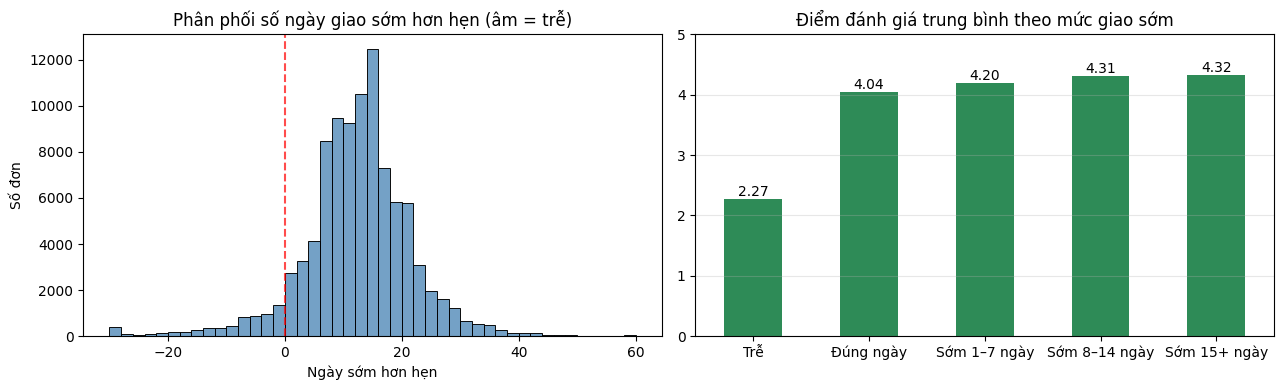

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(early['days_early'].clip(-30, 60), bins=45, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', alpha=.7)
axes[0].set_title('Phân phối số ngày giao sớm hơn hẹn (âm = trễ)')
axes[0].set_xlabel('Ngày sớm hơn hẹn'); axes[0].set_ylabel('Số đơn')
review_by_early['diem_tb'].plot.bar(ax=axes[1], color='seagreen', rot=0)
axes[1].set_ylim(0, 5); axes[1].set_title('Điểm đánh giá trung bình theo mức giao sớm')
axes[1].set_xlabel(''); axes[1].grid(axis='y', alpha=.3)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation**
- Đơn đến sớm hơn hẹn trung bình 11.9 ngày, trung vị 12 ngày. 79% đơn đến sớm từ 7 ngày trở lên,
  và 44% đến sớm từ 14 ngày trở lên.
- Điểm đánh giá gần như phẳng khi đơn đã đến sớm: 4.20 (sớm 1–7 ngày), 4.31 (8–14 ngày), 4.32
  (15+ ngày). Toàn bộ khác biệt nằm giữa "trễ" (2.27) và "không trễ".

**Meaning**
- Ngày hẹn hiện tại xa hơn ngày giao thực tế khoảng 12 ngày. Điểm đánh giá không tăng thêm khi đơn
  đến sớm hơn nữa: sớm 1 tuần hay sớm 3 tuần đều cùng một mức hài lòng. Điểm chỉ giảm khi đơn trễ.
- Điều này cho phép Olist rút ngắn ngày hẹn hiển thị lúc đặt hàng (ví dụ từ trung vị 12 ngày dư
  xuống 4–5 ngày dư) mà không làm giảm điểm đánh giá của phần lớn đơn — miễn là giữ tỷ lệ trễ
  không tăng. Lợi ích của ngày hẹn ngắn hơn (tỷ lệ chuyển đổi lúc mua) không đo được trong dữ liệu
  này, nhưng chi phí của nó về mặt hài lòng gần như bằng không.

**Action**
- Đề xuất thử nghiệm: rút ngắn ngày hẹn theo từng vùng (Southeast trước, vì độ lệch giao hàng thấp
  nhất), theo dõi tỷ lệ trễ và điểm đánh giá. Đây là A/B test thứ hai có thể thiết kế theo khung ở
  notebook 02 phần 4.

## 6. Giao trễ tập trung ở đâu: seller và giao hàng liên bang

Phân rã ba khâu giao hàng (`sql/07_add_delivery_stages.sql`) cho thấy khâu carrier (vận chuyển) chiếm
74% thời gian giao và gần như toàn bộ chênh lệch giữa đơn trễ và đúng hẹn. Hai câu hỏi tiếp theo giúp biến kết luận đó thành hành động:
giao trễ có tập trung ở một số seller không (để cảnh báo đúng chỗ), và bao nhiêu phần chậm trễ đến
từ việc seller và khách ở khác bang (để hiểu giới hạn của việc sửa).

### 6.1. Giao trễ tập trung ở seller nào, và vì sao?

Hai câu hỏi tách bạch. *Tập trung đến mức nào*: bao nhiêu seller gây ra phần lớn đơn trễ. *Tập
trung vì sao*: vì họ bán nhiều đơn (đơn trễ tăng theo số đơn bán ra) hay vì họ giao kém (tỷ lệ trễ cao hơn
hẳn). Hai nguyên nhân dẫn tới hai hành động khác nhau: hỗ trợ vận chuyển cho seller lớn, hay xử lý
từng seller kém. Đơn có nhiều seller (1.3%) được tính cho từng seller.

In [14]:
seller_orders = (items[['order_id', 'seller_id']].drop_duplicates()
                 .merge(orders[['order_id', 'is_late', 'order_review_score', 'order_delivery_day',
                                'total_payment_value']], on='order_id'))

seller_perf = seller_orders.groupby('seller_id').agg(
    so_don       = ('order_id', 'size'),
    so_don_tre   = ('is_late', 'sum'),
    ty_le_tre    = ('is_late', 'mean'),
    diem_tb      = ('order_review_score', 'mean'),
    ngay_giao_tb = ('order_delivery_day', 'mean'),
    doanh_thu    = ('total_payment_value', 'sum'),
).sort_values('so_don_tre', ascending=False)
seller_perf['ty_le_tre'] = seller_perf['ty_le_tre'] * 100

n_sellers  = len(seller_perf)
tong_tre   = seller_perf['so_don_tre'].sum()
tong_don   = seller_perf['so_don'].sum()
ty_le_chung = orders['is_late'].mean() * 100

# Xếp seller theo số đơn trễ giảm dần; tích luỹ % đơn trễ và % tổng đơn
seller_perf['pct_don_tre_tich_luy'] = seller_perf['so_don_tre'].cumsum() / tong_tre * 100
seller_perf['pct_don_tich_luy']     = seller_perf['so_don'].cumsum()     / tong_don * 100

# Mức tập trung: nhóm top X% seller chiếm bao nhiêu % đơn trễ, và bao nhiêu % tổng đơn
rows = []
for pct in [1, 5, 10, 20]:
    k = int(round(n_sellers * pct / 100))
    rows.append({'Nhóm seller (theo số đơn trễ)': f'Top {pct}%',
                 'Số seller': k,
                 '% tổng đơn trễ': round(seller_perf['pct_don_tre_tich_luy'].iloc[k-1], 1),
                 '% tổng đơn':     round(seller_perf['pct_don_tich_luy'].iloc[k-1], 1)})
concentration = pd.DataFrame(rows).set_index('Nhóm seller (theo số đơn trễ)')

print(f"{n_sellers:,} seller có đơn đã giao · tỷ lệ trễ chung {ty_le_chung:.2f}%")
print(f"Số seller ít nhất để bao phủ một nửa số đơn trễ: "
      f"{(seller_perf['pct_don_tre_tich_luy'] < 50).sum() + 1}\n")
print("Nếu % tổng đơn trễ ≈ % tổng đơn: seller trễ nhiều đơn chỉ vì bán nhiều đơn. Nếu cao hơn nhiều: seller giao kém.")
concentration

2,970 seller có đơn đã giao · tỷ lệ trễ chung 6.77%
Số seller ít nhất để bao phủ một nửa số đơn trễ: 98

Nếu % tổng đơn trễ ≈ % tổng đơn: seller trễ nhiều đơn chỉ vì bán nhiều đơn. Nếu cao hơn nhiều: seller giao kém.


,Số seller,% tổng đơn trễ,% tổng đơn
Nhóm seller (theo số đơn trễ),,,
Top 1%,30,30.1,24.9
Top 5%,148,58.8,49.8
Top 10%,297,74.0,62.8
Top 20%,594,87.6,75.9


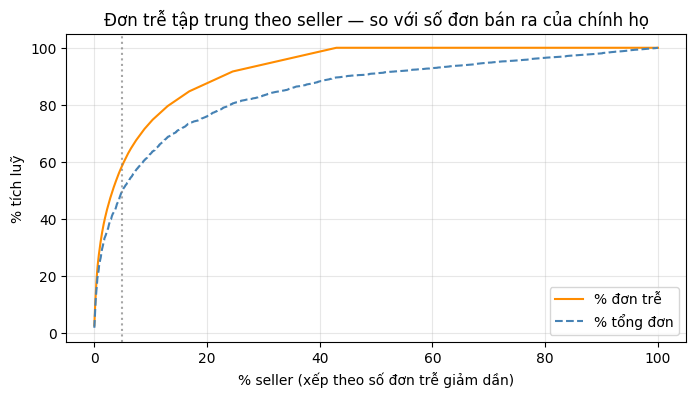

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, n_sellers + 1) / n_sellers * 100
ax.plot(x, seller_perf['pct_don_tre_tich_luy'].values, color='darkorange', label='% đơn trễ')
ax.plot(x, seller_perf['pct_don_tich_luy'].values, color='steelblue', linestyle='--', label='% tổng đơn')
ax.axvline(5, color='grey', linestyle=':', alpha=.7)
ax.set_xlabel('% seller (xếp theo số đơn trễ giảm dần)')
ax.set_ylabel('% tích luỹ')
ax.set_title('Đơn trễ tập trung theo seller — so với số đơn bán ra của chính họ')
ax.legend(); ax.grid(alpha=.3)
plt.show()

Đường cam (đơn trễ) chỉ cao hơn đường xanh (tổng đơn) một chút ở mọi điểm: nhóm seller gây nhiều
đơn trễ nhất cũng chính là nhóm bán nhiều nhất. Bước tiếp theo tách riêng phần "giao kém" ra khỏi
phần "bán nhiều" bằng cách so tỷ lệ trễ, và chỉ xét seller có từ 100 đơn để tỷ lệ có ý nghĩa.

In [16]:
# Tỷ lệ trễ của nhóm top 5% so với phần còn lại: nếu gần bằng nhau, họ trễ nhiều đơn chỉ vì bán nhiều đơn
top5   = seller_perf.head(int(round(n_sellers * 0.05)))
others = seller_perf.iloc[len(top5):]
late_rate_by_group = pd.DataFrame({
    'Số seller':  [len(top5), len(others), n_sellers],
    '% tổng đơn': [top5['so_don'].sum() / tong_don * 100, others['so_don'].sum() / tong_don * 100, 100.0],
    'Tỷ lệ trễ (%)': [top5['so_don_tre'].sum() / top5['so_don'].sum() * 100,
                      others['so_don_tre'].sum() / others['so_don'].sum() * 100,
                      ty_le_chung],
}, index=['Top 5% seller theo số đơn trễ', 'Phần còn lại', 'Toàn sàn']).round(2)

# Seller giao kém rõ rệt: từ 100 đơn trở lên và tỷ lệ trễ gấp đôi mức chung
big = seller_perf[seller_perf['so_don'] >= 100].copy()
nguong_kem = 2 * ty_le_chung
outliers = big[big['ty_le_tre'] > nguong_kem].sort_values('ty_le_tre', ascending=False)

late_rate_by_group

,Số seller,% tổng đơn,Tỷ lệ trễ (%)
Top 5% seller theo số đơn trễ,148,49.81,7.89
Phần còn lại,2822,50.19,5.50
Toàn sàn,2970,100.00,6.77


In [17]:
# Hai danh sách hành động: (a) seller bán nhiều đơn nhất, có nhiều đơn trễ nhất; (b) seller giao kém rõ rệt
watch_list = seller_perf.head(10)[['so_don', 'so_don_tre', 'ty_le_tre', 'diem_tb', 'doanh_thu']].copy()
watch_list['% tổng đơn trễ'] = (watch_list['so_don_tre'] / tong_tre * 100).round(1)
watch_list.index = [s[:8] + '…' for s in watch_list.index]
print("(a) 10 seller có nhiều đơn trễ nhất — ưu tiên hỗ trợ vận chuyển")
display(watch_list.round(2))

outliers_show = outliers[['so_don', 'so_don_tre', 'ty_le_tre', 'diem_tb', 'ngay_giao_tb']].copy()
outliers_show.index = [s[:8] + '…' for s in outliers_show.index]
print(f"\n(b) Seller giao kém rõ rệt: từ 100 đơn, tỷ lệ trễ trên {nguong_kem:.1f}% (gấp đôi mức chung) — "
      f"{len(outliers)} seller, {outliers['so_don_tre'].sum() / tong_tre * 100:.1f}% tổng đơn trễ")
display(outliers_show.round(2))

(a) 10 seller có nhiều đơn trễ nhất — ưu tiên hỗ trợ vận chuyển


,so_don,so_don_tre,ty_le_tre,diem_tb,doanh_thu,% tổng đơn trễ
4a3ca931…,1772,172,9.71,3.85,244444.43,2.6
1f50f920…,1399,124,8.86,4.14,147885.92,1.9
4869f7a5…,1124,118,10.50,4.15,250735.53,1.8
6560211a…,1819,96,5.28,3.98,150809.56,1.5
ea8482cd…,1132,96,8.48,4.03,55237.48,1.5
7c67e144…,973,89,9.15,3.50,239438.31,1.4
cc419e06…,1651,87,5.27,4.15,127678.76,1.3
da8622b1…,1311,87,6.64,4.18,189840.00,1.3
8b321bb6…,930,81,8.71,4.10,31707.11,1.2
955fee92…,1261,77,6.11,4.20,158014.67,1.2



(b) Seller giao kém rõ rệt: từ 100 đơn, tỷ lệ trễ trên 13.5% (gấp đôi mức chung) — 9 seller, 4.6% tổng đơn trễ


,so_don,so_don_tre,ty_le_tre,diem_tb,ngay_giao_tb
06a2c3af…,389,74,19.02,4.01,17.64
88460e8e…,246,42,17.07,3.44,17.76
1ca7077d…,108,18,16.67,2.39,15.48
e5a34388…,216,34,15.74,4.00,15.63
cd68562d…,122,19,15.57,4.02,16.18
2c9e548b…,124,19,15.32,4.13,13.63
431af27f…,116,16,13.79,3.80,17.19
f7ba60f8…,218,30,13.76,4.22,13.34
81602554…,380,52,13.68,3.95,16.16


### 6.2. Giao hàng liên bang

In [18]:
cross = orders.dropna(subset=['seller_state']).groupby('is_cross_state').agg(
    so_don      = ('order_id', 'size'),
    ty_le_tre   = ('is_late', 'mean'),
    ngay_giao   = ('order_delivery_day', 'mean'),
    ngay_transit = ('days_transit', 'mean'),
    diem_tb     = ('order_review_score', 'mean'),
).round(2)
cross.index = cross.index.map({False: 'Cùng bang', True: 'Khác bang'})
cross['ty_le_tre'] = (cross['ty_le_tre'] * 100).round(2)
print(f"Tỷ lệ đơn seller và khách ở khác bang: {orders['is_cross_state'].mean()*100:.1f}%")
cross

Tỷ lệ đơn seller và khách ở khác bang: 64.0%


,so_don,ty_le_tre,ngay_giao,ngay_transit,diem_tb
is_cross_state,,,,,
Cùng bang,34710,5.0,7.89,4.81,4.26
Khác bang,61767,8.0,15.09,11.87,4.10


**Observation**
- Đơn trễ tập trung mạnh theo seller: 5% seller (148) chiếm 59% số đơn trễ, và chỉ cần 98 seller để
  bao phủ một nửa. Nhưng cùng nhóm 148 seller đó cũng bán ra 50% tổng đơn: mức tập trung của đơn
  trễ gần như trùng với mức tập trung của số đơn bán ra.
- Tỷ lệ trễ của nhóm top 5% là 7.9%, so với 5.5% ở phần còn lại — cao hơn, nhưng không phải khác
  biệt về bản chất. Seller giao kém rõ rệt (từ 100 đơn, tỷ lệ trễ gấp đôi mức chung) chỉ có 9, và
  họ gây ra chưa tới 5% tổng đơn trễ.
- 64% đơn có seller và khách ở khác bang. Đơn khác bang mất 15.1 ngày so với 7.9 ngày cùng bang;
  riêng khâu vận chuyển gấp 2.5 lần (11.9 so với 4.8 ngày). Tỷ lệ trễ 8% so với 5%.

**Meaning**
- Đơn trễ tập trung vì *bán nhiều đơn* chứ không vì một nhóm seller *giao kém*. Danh sách cảnh báo seller mà
  dự án đề xuất ban đầu vì thế cần tách làm hai: một danh sách ngắn (khoảng 100 seller lớn) để ưu
  tiên hỗ trợ vận chuyển, vì mỗi điểm phần trăm cải thiện ở họ tác động lên nhiều đơn nhất; và một
  danh sách rất ngắn (9 seller) cần xử lý trực tiếp vì giao kém rõ rệt. Gộp hai danh sách làm một sẽ
  xử lý nhầm seller lớn hoặc bỏ sót seller giao kém.
- Phần lớn chậm trễ là chi phí cấu trúc của việc seller tập trung ở São Paulo còn khách ở khắp
  Brazil. Đây không phải lỗi seller và không sửa được bằng cảnh báo; nó cần quyết định về mạng lưới
  vận chuyển (kho trung chuyển, hợp đồng carrier theo vùng).

**Action**
- Đưa bảng `seller_perf` lên dashboard Operations dưới dạng bảng xếp hạng có lọc theo vùng, với hai
  chế độ sắp xếp: theo số đơn trễ (danh sách hỗ trợ) và theo tỷ lệ trễ với ngưỡng tối thiểu 100 đơn
  (danh sách xử lý).
- Khi báo cáo cho ban lãnh đạo, tách hai phần: phần sửa được ở seller (nhỏ) và phần cấu trúc địa
  lý (lớn), để không kỳ vọng sai vào chương trình cảnh báo.

## 7. Giỏ hàng và hành vi mua lại

Giả thuyết ban đầu thứ hai của dự án là giá trị khách có thể tăng bằng bán chéo trong giỏ hàng, bán
thêm và chương trình khách hàng thân thiết. Phần này kiểm tra xem dữ liệu có chỗ cho các đề xuất đó
không, qua bốn câu hỏi: giỏ hàng có bao nhiêu món, danh mục nào có giá trị đơn cao và trả góp liên
hệ thế nào với giá trị đơn, khách quay lại mua gì so với lần đầu, và lần mua đầu ở danh mục nào thì
hay quay lại.

### 7.1. Giỏ hàng có gì để bán chéo?

In [19]:
with_basket = orders.dropna(subset=['n_items'])
print(f"Đơn có từ 2 món trở lên:              {(with_basket['n_items'] >= 2).mean()*100:.1f}%")
print(f"Đơn có từ 2 sản phẩm khác nhau trở lên: {(with_basket['n_products'] >= 2).mean()*100:.1f}%")
print(f"Đơn có từ 2 seller trở lên:           {(with_basket['n_sellers'] >= 2).mean()*100:.1f}%")

Đơn có từ 2 món trở lên:              10.0%
Đơn có từ 2 sản phẩm khác nhau trở lên: 3.3%
Đơn có từ 2 seller trở lên:           1.3%


**Observation**
- 10% đơn có từ 2 món, nhưng phần lớn là mua nhiều đơn vị cùng một sản phẩm. Chỉ 3.3% đơn có hai
  sản phẩm khác nhau và 1.3% có hàng từ hai seller.

**Meaning**
- Giỏ hàng Olist về cơ bản là một món. Không có đủ đơn nhiều sản phẩm để học được cặp sản phẩm
  nào hay đi cùng nhau, nên phân tích giỏ hàng (market basket) và gợi ý bán chéo tại trang thanh
  toán không có cơ sở dữ liệu. Giả thuyết bán chéo không đứng vững.

**Action**
- Thay câu hỏi "bán chéo trong cùng đơn" bằng "bán tiếp ở lần mua sau": khách quay lại mua gì (7.3).

### 7.2. Danh mục và trả góp

In [20]:
cat_stats = (with_basket.groupby('category')
             .agg(so_don=('order_id', 'size'), aov=('total_payment_value', 'mean'))
             .query('so_don >= 500')
             .sort_values('aov', ascending=False).round(1))
print("Danh mục có giá trị đơn cao nhất (từ 500 đơn):")
print(cat_stats.head(5).to_string())
print("\nDanh mục có giá trị đơn thấp nhất:")
print(cat_stats.tail(3).to_string())

Danh mục có giá trị đơn cao nhất (từ 500 đơn):
                                 so_don    aov
category                                      
musical_instruments                 607  333.0
small_appliances                    606  326.4
office_furniture                   1246  268.1
watches_gifts                      5472  230.6
construction_tools_construction     728  224.5

Danh mục có giá trị đơn thấp nhất:
                          so_don   aov
category                              
fashion_bags_accessories    1810  99.3
telephony                   4076  93.1
electronics                 2507  80.6


In [21]:
inst = orders.dropna(subset=['order_payment_installment']).copy()
inst['inst_band'] = pd.cut(inst['order_payment_installment'], bins=[0, 1, 3, 6, 12, 99],
                           labels=['1 kỳ', '2–3 kỳ', '4–6 kỳ', '7–12 kỳ', '13+ kỳ'])
inst_stats = (inst.groupby('inst_band', observed=True)['total_payment_value']
              .agg(so_don='size', gia_tri_tb='mean', gia_tri_trung_vi='median').round(1))
inst_stats['pct_don'] = (inst_stats['so_don'] / inst_stats['so_don'].sum() * 100).round(1)
inst_stats

,so_don,gia_tri_tb,gia_tri_trung_vi,pct_don
inst_band,,,,
1 kỳ,47011,120.6,79.6,48.7
2–3 kỳ,22021,135.0,111.6,22.8
4–6 kỳ,15694,181.8,128.0,16.3
7–12 kỳ,11570,332.8,205.6,12.0
13+ kỳ,179,416.0,252.1,0.2


**Observation**
- Giá trị đơn cao nhất ở nhạc cụ (R$333), đồ gia dụng nhỏ (R$326), nội thất văn phòng (R$268);
  thấp nhất ở điện tử (R$81) và điện thoại (R$93).
- Đơn trả 1 kỳ có giá trị trung vị R$80; đơn trả 7–12 kỳ có trung vị R$206, gấp 2.6 lần. Gần một
  nửa đơn trả một kỳ, nhưng đơn trả từ 4 kỳ trở lên chiếm 29% số đơn.

**Meaning**
- Trả góp đi cùng đơn giá trị cao là hệ quả chứ không phải nguyên nhân: khách chia nhỏ khoản lớn.
  Không thể kết luận "khuyến khích trả góp làm tăng AOV" từ dữ liệu này. Điều có thể kết luận là
  với các danh mục giá trị cao (nội thất, gia dụng), phương án trả góp là điều kiện để bán được,
  nên phí giao dịch trả góp là chi phí bán hàng của các danh mục đó.

**Action**
- Nếu đàm phán phí với đối tác tài chính, ưu tiên theo danh mục giá trị cao thay vì đại trà.

### 7.3. Khách quay lại mua gì?

Với 2,015 khách mua lại: lần mua thứ hai có cùng danh mục với lần đầu không, và có mua từ cùng
seller không. Đây là căn cứ để thiết kế nội dung chiến dịch giữ chân — gợi ý lại thứ đã mua hay gợi
ý thứ khác.

In [22]:
rep = orders[orders['is_repeat_customer']].sort_values('order_purchase_date')
occ1 = rep[rep['purchase_seq'] == 1].groupby('customer_unique_id').agg(cat1=('category', 'first'))
occ2 = rep[rep['purchase_seq'] == 2].groupby('customer_unique_id').agg(cat2=('category', 'first'))
pair = occ1.join(occ2, how='inner').dropna()

sellers_by_occ = (items[['order_id', 'seller_id']]
                  .merge(rep[['order_id', 'customer_unique_id', 'purchase_seq']], on='order_id'))
s1 = sellers_by_occ[sellers_by_occ['purchase_seq'] == 1].groupby('customer_unique_id')['seller_id'].apply(set)
s2 = sellers_by_occ[sellers_by_occ['purchase_seq'] == 2].groupby('customer_unique_id')['seller_id'].apply(set)
same_seller = pd.concat([s1, s2], axis=1, keys=['a', 'b']).dropna()
same_seller_rate = same_seller.apply(lambda r: len(r['a'] & r['b']) > 0, axis=1).mean() * 100

print(f"Khách mua lại có đủ thông tin: {len(pair):,}")
print(f"Lần mua 2 cùng danh mục với lần 1: {(pair['cat1'] == pair['cat2']).mean()*100:.1f}%")
print(f"Lần mua 2 có cùng seller với lần 1: {same_seller_rate:.1f}%")

print("\nDanh mục được mua lại nhiều nhất (lần 2 cùng danh mục lần 1):")
(pair[pair['cat1'] == pair['cat2']]['cat1'].value_counts().head(8))

Khách mua lại có đủ thông tin: 2,015
Lần mua 2 cùng danh mục với lần 1: 38.4%
Lần mua 2 có cùng seller với lần 1: 25.3%

Danh mục được mua lại nhiều nhất (lần 2 cùng danh mục lần 1):


cat1
bed_bath_table           113
sports_leisure           104
health_beauty             80
furniture_decor           55
computers_accessories     53
watches_gifts             51
housewares                37
telephony                 33
Name: count, dtype: int64

### 7.4. Lần mua đầu ở danh mục nào thì hay quay lại?

In [23]:
cat_repeat = (first.dropna(subset=['first_category'])
              .groupby('first_category')['is_repeat']
              .agg(so_khach='size', ty_le_mua_lai='mean')
              .query('so_khach >= 1000'))
cat_repeat['ty_le_mua_lai'] = (cat_repeat['ty_le_mua_lai'] * 100).round(2)
cat_repeat = cat_repeat.sort_values('ty_le_mua_lai', ascending=False)
cat_repeat

,so_khach,ty_le_mua_lai
first_category,,
fashion_bags_accessories,1688,3.79
furniture_decor,5938,2.85
bed_bath_table,8722,2.79
sports_leisure,7198,2.72
pet_shop,1629,2.64
garden_tools,3330,2.49
perfumery,2987,2.38
telephony,3991,2.15
housewares,5502,2.13


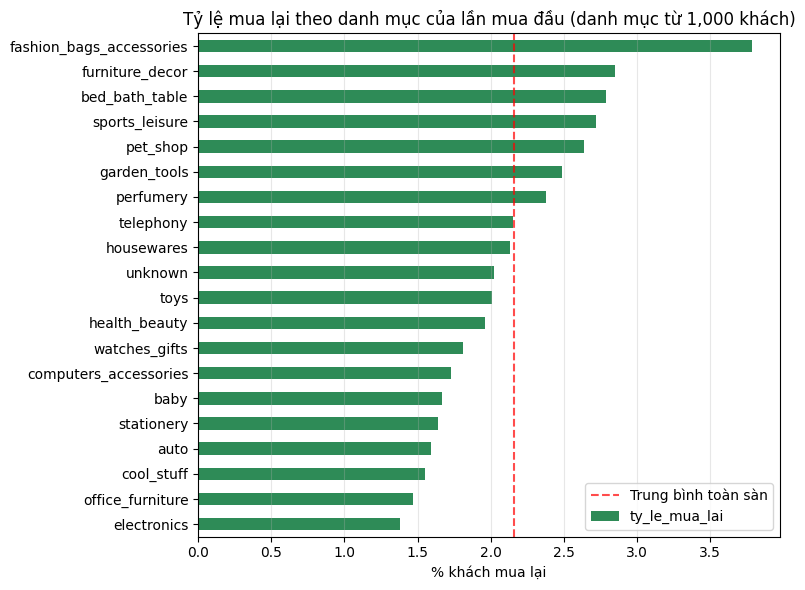

In [24]:
plt.figure(figsize=(8, 6))
cat_repeat['ty_le_mua_lai'].sort_values().plot.barh(color='seagreen')
plt.axvline(first['is_repeat'].mean() * 100, color='red', linestyle='--', alpha=.7, label='Trung bình toàn sàn')
plt.xlabel('% khách mua lại'); plt.ylabel('')
plt.title('Tỷ lệ mua lại theo danh mục của lần mua đầu (danh mục từ 1,000 khách)')
plt.legend(); plt.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.show()

**Observation**
- 38% khách mua lại chọn đúng danh mục đã mua lần đầu, và 25% mua lại từ chính seller cũ. Với 71
  danh mục và gần 3,000 seller, hai tỷ lệ này cao hơn nhiều so với ngẫu nhiên.
- Danh mục lần đầu ảnh hưởng rõ đến việc quay lại: túi xách và phụ kiện thời trang 3.8%, trang trí
  nhà và chăn ga gối 2.8–2.9%, so với điện tử 1.4% và nội thất văn phòng 1.5%. Chênh lệch gần 3 lần.

**Meaning**
- Khách quay lại vì *nhu cầu lặp lại* (đồ gia dụng, thời trang, thú cưng) chứ không vì gắn bó với
  sàn. Danh mục mua một lần rồi xong (điện tử, nội thất văn phòng) không sinh khách quay lại dù giá
  trị đơn cao.
- Đây là căn cứ cho chiến dịch giữ chân (notebook 02 phần 3): nội dung nên là gợi ý *cùng danh mục
  hoặc cùng seller* với lần mua đầu, không phải giảm giá chung. Và ngân sách thu hút khách mới nên
  nghiêng về danh mục có nhu cầu lặp.

**Action**
- Cá nhân hoá win-back theo danh mục lần đầu; bắt đầu từ ba danh mục có tỷ lệ mua lại cao nhất.
- Bổ sung `first_category` vào tiêu chí chia nhóm A/B test ở notebook 02 phần 4, vì nó ảnh hưởng
  đến tỷ lệ quay lại nền của từng nhóm.

## 8. Ghi kết quả xuống data warehouse

Hai bảng mới cho Power BI, cùng nguyên tắc với `fact_rfm_segments`: notebook tính một lần, dashboard
chỉ đọc, để mọi con số trên báo cáo trùng với notebook.

- `gold.fact_order_experience` — một dòng mỗi đơn: thứ tự lần mua, nhãn khách mua lại, số ngày giao
  sớm, cờ giao trễ, cờ khác bang, số món và số sản phẩm, danh mục, bang của seller.
- `gold.dim_seller_performance` — một dòng mỗi seller: số đơn, số đơn trễ, tỷ lệ trễ, điểm đánh giá,
  thời gian giao trung bình, doanh thu.

In [25]:
order_exp = orders[['order_id', 'customer_unique_id', 'purchase_seq', 'is_repeat_customer',
                    'is_late', 'days_early', 'is_cross_state', 'n_items', 'n_products', 'n_sellers',
                    'category', 'seller_state']].copy()
order_exp['is_cross_state'] = order_exp['is_cross_state'].where(order_exp['seller_state'].notna())

seller_out = seller_perf.drop(columns=['pct_don_tre_tich_luy', 'pct_don_tich_luy']).reset_index()
seller_out.columns = ['seller_id', 'n_orders', 'late_orders', 'late_rate_pct',
                      'avg_review_score', 'avg_delivery_days', 'revenue']

order_exp.to_sql('fact_order_experience', engine, schema='gold', if_exists='replace', index=False)
seller_out.to_sql('dim_seller_performance', engine, schema='gold', if_exists='replace', index=False)

with engine.begin() as conn:
    conn.execute(text("ALTER TABLE gold.fact_order_experience ADD PRIMARY KEY (order_id)"))
    conn.execute(text("ALTER TABLE gold.dim_seller_performance ADD PRIMARY KEY (seller_id)"))

print(f"Đã ghi {len(order_exp):,} dòng vào gold.fact_order_experience "
      f"và {len(seller_out):,} dòng vào gold.dim_seller_performance")

Đã ghi 96,477 dòng vào gold.fact_order_experience và 2,970 dòng vào gold.dim_seller_performance


In [26]:
# Nghiệm thu: số đơn và số khách mua lại phải khớp với phần 1
pd.read_sql("""
    SELECT COUNT(*)                                            AS so_don,
           COUNT(DISTINCT customer_unique_id)                  AS so_khach,
           COUNT(DISTINCT CASE WHEN is_repeat_customer THEN customer_unique_id END) AS khach_mua_lai,
           ROUND(AVG(CASE WHEN is_late THEN 1 ELSE 0 END) * 100, 2) AS ty_le_tre_pct
    FROM gold.fact_order_experience
""", engine)

,so_don,so_khach,khach_mua_lai,ty_le_tre_pct
0,96477,93357,2015,6.77


## 9. Kết luận

**Về giả thuyết trung tâm của dự án** — rằng khách rời đi vì trải nghiệm xấu —
dữ liệu cho câu trả lời hai mặt. Trải nghiệm xấu ở lần mua đầu có làm giảm xác suất quay lại
(từ 2.2% xuống 1.6–1.7%), nhưng ngay cả khách hài lòng cũng chỉ quay lại 2.2%. Vận hành giải thích
được một phần tư khoảng cách giữa khách một lần và khách mua lại; ba phần tư còn lại là do khách
không có lý do quay lại. Kết luận này khớp với notebook 01 (không có phân khúc Champions) và
notebook 02 (chỉ 1.2% tự tái kích hoạt).

**Bốn phát hiện có thể hành động:**

1. **Ngày hẹn giao đang dư khoảng 12 ngày** và khách không hài lòng hơn khi nhận sớm hơn nữa
   (4.20–4.32 sao ở mọi mức giao sớm). Olist có thể rút ngắn ngày hẹn hiển thị mà không mất điểm
   đánh giá, miễn giữ tỷ lệ trễ.
2. **Giao trễ tập trung ở 5% seller (59% số đơn trễ) nhưng do bán nhiều đơn, không phải do giao kém:**
   cùng nhóm đó bán ra 50% tổng đơn, và chỉ 9 seller giao kém rõ rệt (gây dưới 5% đơn trễ). Phần lớn
   chậm trễ là cấu trúc: 64% đơn đi liên bang với thời gian vận chuyển gấp 2.5 lần. Cần hai danh
   sách khác nhau — hỗ trợ seller lớn và xử lý seller kém — thay vì một danh sách cảnh báo chung.
3. **Giao trễ gây ra một phần ba đánh giá xấu.** Sáu trong mười đơn trễ bị 1–2 sao, nhưng hai phần
   ba đánh giá 1–2 sao đến từ đơn đúng hẹn — nguyên nhân sản phẩm cần phân tích riêng bằng bình
   luận văn bản.
4. **Không có gì để bán chéo trong đơn (3.3% đơn có hai sản phẩm), nhưng có nhiều thứ để bán tiếp:**
   38% khách quay lại mua cùng danh mục, 25% mua cùng seller, và danh mục có nhu cầu lặp (thời trang,
   gia dụng, thú cưng) sinh khách quay lại gấp gần 3 lần danh mục mua một lần (điện tử).

**Điều chỉnh so với giả thuyết ban đầu:** rút đề xuất bán chéo tại trang thanh toán; thay
bằng win-back cá nhân hoá theo danh mục và seller của lần mua đầu. Giữ đề xuất cảnh báo seller nhưng
đổi thành ưu tiên hỗ trợ vận chuyển cho seller bán nhiều đơn. Thêm đề xuất mới: rút ngắn ngày hẹn giao.

**Hạn chế:**

- Mọi so sánh đều là quan sát, không phải thí nghiệm. Khách ở vùng xa vừa bị giao chậm vừa trả phí
  cao vừa ít quay lại; không tách được ba yếu tố này khỏi nhau bằng dữ liệu hiện có.
- Tỷ lệ mua lại theo nhóm dựa trên 2,015 khách mua lại; khi chia theo danh mục hoặc vùng nhỏ, một
  vài chục khách đã đủ làm đổi thứ hạng. Chỉ các danh mục từ 1,000 khách và các vùng lớn được kết luận.
- Danh mục của đơn lấy theo món đầu tiên; với 3.3% đơn nhiều sản phẩm, điều này có thể gán sai danh mục.
- Tỷ lệ giao trễ trong notebook này (6.8%) theo định nghĩa của lớp gold: giao *sau* ngày hẹn. Nếu
  tính theo timestamp (đơn giao đúng ngày hẹn cũng là trễ, vì mốc hẹn là 0 giờ) thì tỷ lệ là 8.1%.
  Mọi so sánh trong notebook chỉ dùng một định nghĩa nên kết luận không đổi, nhưng con số tuyệt đối
  phải đọc kèm định nghĩa.